# 01 - Data Understanding & Cleaning

**Goal:** Load the raw Telco Customer Churn dataset, understand its structure, identify data quality issues, and produce a clean dataset for downstream EDA and modeling.

**Dataset:** [Telco Customer Churn (IBM Sample Dataset)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — 7,043 customer records with 21 columns describing demographics, account information, subscribed services, and churn status.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [57]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

In [58]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [59]:
df.shape

(7043, 21)

In [60]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [62]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [63]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [64]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2790,5013-SBUIH,Female,0,No,No,50,Yes,Yes,Fiber optic,Yes,Yes,No,Yes,Yes,Yes,Two year,Yes,Electronic check,109.65,5551.15,Yes
2141,6648-INWPS,Male,0,Yes,Yes,16,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,20.15,341.35,No
1459,3070-BDOQC,Female,0,No,No,60,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Electronic check,99.65,5941.05,No
6419,3865-ZYKAD,Male,1,Yes,No,69,Yes,Yes,Fiber optic,Yes,Yes,No,No,No,No,Month-to-month,Yes,Credit card (automatic),84.90,5785.65,No
5248,3239-TPHPZ,Female,0,Yes,No,12,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Electronic check,20.05,264.55,No


In [65]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [66]:
df["TotalCharges"].unique()[:20]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8',
       '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25',
       '528.35', '1862.9'], dtype=object)

In [67]:
df["Churn"].value_counts(normalize=True)
#data/class imbalance

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [68]:
df["TotalCharges"].value_counts().head(10)

TotalCharges
         11
20.2     11
19.75     9
20.05     8
19.9      8
19.65     8
45.3      7
19.55     7
20.15     6
20.25     6
Name: count, dtype: int64

In [69]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### Initial observations

- Dataset contains 7,043 rows (customer records) and 21 columns
- No null or missing values detected (via `.isnull()`)
- Most variables are categorical
- `TotalCharges` is stored as an object/string, and needs to be converted to numeric
- Target variable (`Churn`) is imbalanced, so accuracy alone won't be a sufficient evaluation metric

In [70]:
df["TotalCharges"].dtype

dtype('O')

In [71]:
print((df["TotalCharges"] == " ").sum())

11


In [72]:
df["TotalCharges"].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object

In [73]:
df["TotalCharges"].apply(type).value_counts()



TotalCharges
<class 'str'>    7043
Name: count, dtype: int64

In [74]:
df[df["TotalCharges"]==" "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


All the records with blank `TotalCharges` have `MonthlyCharges` below 61, all have `tenure` = 0, none of them churned, gender is mixed, and all of them have a 2-year contract. These are almost certainly brand-new customers who haven't been billed yet — so the blanks are legitimately 0, not missing data.

In [75]:
#so that when we convert the column the 0 values dont get replaced by nan
df["TotalCharges"] = df["TotalCharges"].replace(" ", 0)
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [76]:
#verification
print((df["TotalCharges"] == " ").sum())

0


In [77]:
df["TotalCharges"].dtype

dtype('float64')

In [78]:
df[df["tenure"] == 0][["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,0.0
753,0,20.25,0.0
936,0,80.85,0.0
1082,0,25.75,0.0
1340,0,56.05,0.0
3331,0,19.85,0.0
3826,0,25.35,0.0
4380,0,20.00,0.0
5218,0,19.70,0.0
6670,0,73.35,0.0


### Churn is heavily dependent on tenure

- Customers are more likely to churn in the early months
- Churn decreases significantly as tenure increases
- Long-term customers show strong retention behavior

In [80]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No":0})
df["Churn"]


0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [81]:
df["Churn"].unique()

array([0, 1])

In [82]:
df["Churn"].value_counts(dropna=False)

Churn
0    5174
1    1869
Name: count, dtype: int64

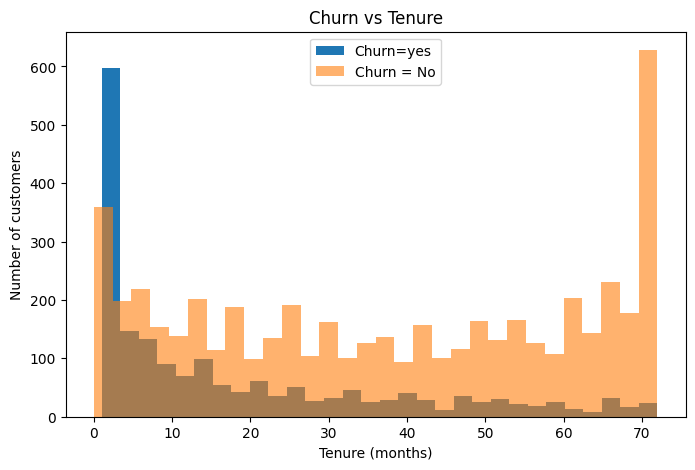

In [84]:
import matplotlib.pyplot as plt

churn_yes = df[df["Churn"]==1]["tenure"]
churn_no = df[df["Churn"] == 0]["tenure"]

plt.figure(figsize=(8,5))
plt.hist(churn_yes, bins=30, alpha=1, label= "Churn=yes")
plt.hist(churn_no, bins=30, alpha=0.6, label="Churn = No")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of customers")
plt.title("Churn vs Tenure")
plt.legend()

plt.show()


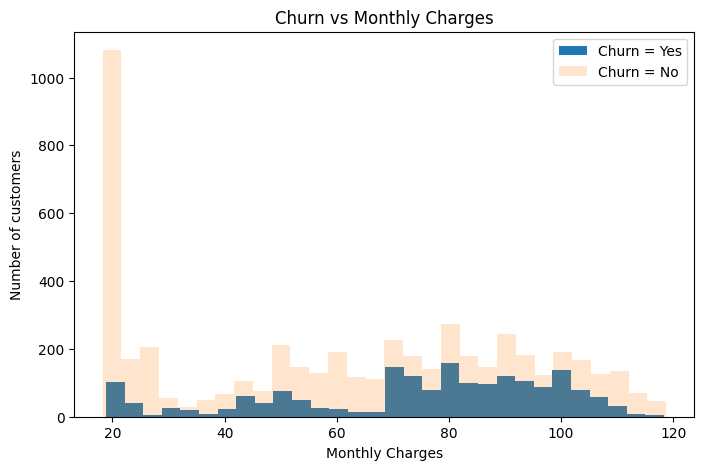

In [89]:
plt.figure(figsize = (8,5))

plt.hist(df[df["Churn"]== 1]["MonthlyCharges"], bins = 30 , alpha=1, label = "Churn = Yes")
plt.hist(df[df["Churn"] == 0]["MonthlyCharges"], bins=30, alpha=0.2, label="Churn = No")

plt.xlabel("Monthly Charges")
plt.ylabel("Number of customers")
plt.title("Churn vs Monthly Charges")
plt.legend()

plt.show()

### Insight: Monthly charges influence churn behavior

- Customers with higher monthly charges show higher churn tendency.
- However, churn is not solely driven by price, indicating other factors (e.g., contract type, tenure) also play a role.

In [91]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
0    61.265124
1    74.441332
Name: MonthlyCharges, dtype: float64

In [92]:
df["charge_bin"] = pd.cut(df["MonthlyCharges"], bins=5)

df.groupby("charge_bin")["Churn"].mean()

charge_bin
(18.15, 38.35]     0.114079
(38.35, 58.45]     0.269652
(58.45, 78.55]     0.294806
(78.55, 98.65]     0.369660
(98.65, 118.75]    0.300573
Name: Churn, dtype: float64

### Insight: Monthly charges increase churn probability

- Customers in higher monthly charge segments exhibit higher churn rates.
- However, total churn count is influenced by customer distribution across pricing tiers.
- This indicates price sensitivity exists, but is not the sole driver of churn.

### Final cleaned dataset preview

In [97]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,charge_bin
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,"(18.15, 38.35]"
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,"(38.35, 58.45]"
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,"(38.35, 58.45]"
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,"(38.35, 58.45]"
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,"(58.45, 78.55]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,"(78.55, 98.65]"
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,"(98.65, 118.75]"
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,"(18.15, 38.35]"
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1,"(58.45, 78.55]"


### Save cleaned dataset for downstream notebooks

In [98]:
df.to_csv("../data/processed/telco_churn_clean.csv", index=False)

### Summary

- Converted `TotalCharges` to numeric (blank values → 0 for brand-new customers)
- Encoded `Churn` as a binary integer (1 = churned, 0 = stayed)
- Confirmed no missing values remain
- Saved the cleaned dataset to `data/processed/telco_churn_clean.csv`

**Next:** [`02_eda.ipynb`](./02_eda.ipynb) — deeper exploratory analysis of churn drivers.